In [1]:
import os
import pickle

import numpy as np
import pandas as pd
import scipy

import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import plotly.express as px

from tqdm.notebook import tqdm, trange


from pyphylon.pangenome import estimate_pan_core_size, fit_heaps_by_iteration
from pyphylon.util import load_config

In [2]:
import random

random.seed(42) # set random seed for reproducibility

In [3]:
matplotlib.rcParams['pdf.fonttype'] = 42
plt.rcParams["figure.dpi"] = 300
sns.set_palette("deep")
sns.set_context("paper")
sns.set_style("whitegrid")

In [4]:
df_genes = pd.read_csv('/mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/panaroo_results/gene_presence_absence.Rtab', sep = '\t').set_index('Gene')

display(
    df_genes.shape,
    df_genes.head()
)

(43601, 1317)

,GCA_048593205.1,GCA_051016185.1,GCF_000006765.1,GCF_000014625.1,GCF_000026645.1,GCF_000168335.1,GCF_000223945.1,GCF_000223965.1,GCF_000226155.1,GCF_000271365.1,...,GCF_902172305.2,GCF_902703185.1,GCF_902703195.1,GCF_902703215.1,GCF_904866275.1,GCF_905071885.1,GCF_951691365.1,GCF_951802375.2,GCF_951805275.2,GCF_976988945.1
Gene,,,,,,,,,,,,,,,,,,,,,
rpsK,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
group_38282,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
group_38069,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
arfA,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
rpmG,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [5]:
metadata = pd.read_csv('/mnt/craig/pan_phylon/P_aeruginosa/data/interim/2b_ncbi_mash_scrubbed_species_metadata.csv', index_col=0, dtype='object')

display(
    metadata.shape,
    metadata.head()
)

(1317, 83)

,genome_id,genome_name,organism_name,taxon_id,genome_status,strain,culture_collection,type_strain,completion_date,bioproject_accession,...,assembly_stats_genome_coverage,assembly_stats_atgc_count,organism_infraspecific_names_strain,organism_infraspecific_names_isolate,assembly_stats_total_number_of_chromosomes,wgs_project_accession,annotation_count_gene_total,annotation_count_gene_protein_coding,annotation_count_gene_pseudogene,mash_cluster
0,GCA_048593205.1,Pseudomonas aeruginosa ps1,Pseudomonas aeruginosa,287,Complete,ps1,NaN,NaN,2025-03-17,PRJNA1226941,...,50.0,6037891,ps1,NaN,1.0,NaN,5601.0,5416.0,121.0,62
1,GCA_051016185.1,Pseudomonas aeruginosa 25181,Pseudomonas aeruginosa,287,Complete,25181,NaN,NaN,2025-06-21,PRJNA1180571,...,34.0,7421260,25181,NaN,2.0,NaN,7102.0,6922.0,95.0,2
2,GCF_000006765.1,Pseudomonas aeruginosa PAO1,Pseudomonas aeruginosa PAO1,208964,Complete,PAO1,NaN,NaN,2006-07-24,PRJNA331,...,NaN,6264404,PAO1,NaN,1.0,NaN,5697.0,5572.0,19.0,34
3,GCF_000014625.1,Pseudomonas aeruginosa UCBPP-PA14,Pseudomonas aeruginosa UCBPP-PA14,208963,Complete,UCBPP-PA14,NaN,NaN,2006-10-06,PRJNA386,...,NaN,6537637,UCBPP-PA14,NaN,1.0,NaN,6041.0,5891.0,70.0,2
4,GCF_000026645.1,Pseudomonas aeruginosa LESB58,Pseudomonas aeruginosa LESB58,557722,Complete,LESB58,NaN,NaN,2008-12-24,PRJEA31101,...,NaN,6601757,LESB58,NaN,1.0,NaN,6195.0,6059.0,52.0,94


# Heaps' Law Plot for CAR genomes

In [6]:
import scipy.sparse
from scipy.sparse import coo_matrix

def estimate_pan_core_size(df_genes, num_iter=10, log_batch=1):
    '''
    Computes pan/core genome size curves for many randomizations
    '''
    num_genes, num_strains = df_genes.shape
    
    gene_data = df_genes.sparse.to_coo()
    
    gene_data = gene_data.T.tocsr() # now strain x cluster
    pan_genomes = np.zeros((num_iter, num_strains)) # estimated pan-genome curve per iteration
    core_genomes = np.zeros((num_iter, num_strains)) # estimated core-genome curve per iteration
    
    acc_genomes = np.zeros((num_iter, num_strains)) # estimated acc-genome curve per iteration
    rare_genomes = np.zeros((num_iter, num_strains)) # estimated rare-genome curve per iteration

    ''' Simulate pan/core-genomes for randomly ordered strains '''
    for i in trange(num_iter):
        if (i+1) % log_batch == 0:
            print('Iteration', i+1, 'of', num_iter)
        shuffle_indices = np.arange(num_strains)
        np.random.shuffle(shuffle_indices)
        gene_incidence = np.zeros(num_genes, dtype='int')
        for j,shuffle_col in enumerate(shuffle_indices):
            gene_incidence += gene_data[shuffle_col,:]
            #print(gene_incidence)
            pan_genomes[i,j] = (gene_incidence > 0).sum()
            core_genomes[i,j] = (gene_incidence >= (j+1)*0.987).sum()
            
            acc_genomes[i,j] = ((gene_incidence > j*0.037 ) & (gene_incidence < (j+1)*0.987)).sum()
            rare_genomes[i,j] = ((gene_incidence > 0 ) & (gene_incidence < j*0.037)).sum()

    ''' Save to DataFrame '''
    iter_index = map(lambda x: 'Iter' + str(x), range(1,num_iter+1))
    pan_cols = list(map(lambda x: 'Pan' + str(x), range(1,num_strains+1)))
    core_cols = list(map(lambda x: 'Core' + str(x), range(1,num_strains+1)))
    
    acc_cols = list(map(lambda x: 'Acc' + str(x), range(1,num_strains+1)))
    rare_cols = list(map(lambda x: 'Rare' + str(x), range(1,num_strains+1)))
    
    df_pan_core = pd.DataFrame(index=iter_index, columns=pan_cols + core_cols + acc_cols + rare_cols,
                               data=np.hstack([pan_genomes, core_genomes, acc_genomes, rare_genomes]))
    return df_pan_core


def fit_heaps(df_freqs):
    ''' Fits a single iteration to Heaps Law: PG size = kappa * (genes)^lambda_ '''
    heaps = lambda x, lambda_, kappa: kappa * np.power(x, lambda_)
    n_strains = df_freqs.shape[0]
    p0 = [0.5, float(min(df_freqs.values))]
    popt, pcov = scipy.optimize.curve_fit(heaps, 
        np.arange(1,n_strains+1), df_freqs.values, p0=p0)
    return popt


def fit_heaps_by_iteration(df_pan_core, section='pan'):
    ''' Fits Heaps Law to each iteration and returns lambda_ and kappa for each iteration '''
    #df = df_pan_core.iloc[:,:int(df_pan_core.shape[1]/2)].T
    if section.lower() == 'pan':
        df = df_pan_core[ [x for x in df_pan_core.columns if 'Pan' in x] ].T
    elif section.lower() == 'core':
        df = df_pan_core[ [x for x in df_pan_core.columns if 'Core' in x] ].T
    elif section.lower() == 'acc':
        df = df_pan_core[ [x for x in df_pan_core.columns if 'Acc' in x] ].T
    elif section.lower() == 'rare':
        df = df_pan_core[ [x for x in df_pan_core.columns if 'Rare' in x] ].T
    
    n_samples, n_iters = df.shape
    heaps_fits = {}
    for i,iter_label in enumerate(df.columns):
        lambda_, kappa = fit_heaps(df.iloc[:,i])
        heaps_fits[iter_label] = {'lambda_': lambda_, 'kappa': kappa}
    return pd.DataFrame.from_dict(heaps_fits, orient='index').reindex(df.columns)

In [7]:
# # Generate sparse dataframe (needed for function to work)
df_genes_sparse = df_genes.astype(pd.SparseDtype("int8", 0))

# Estimate pan/core curve
df_pan_core = estimate_pan_core_size(df_genes_sparse, num_iter=20, log_batch=1) # generate pan/core size curves

  0%|          | 0/20 [00:00<?, ?it/s]

Iteration 1 of 20
Iteration 2 of 20
Iteration 3 of 20
Iteration 4 of 20
Iteration 5 of 20
Iteration 6 of 20
Iteration 7 of 20
Iteration 8 of 20
Iteration 9 of 20
Iteration 10 of 20
Iteration 11 of 20
Iteration 12 of 20
Iteration 13 of 20
Iteration 14 of 20
Iteration 15 of 20
Iteration 16 of 20
Iteration 17 of 20
Iteration 18 of 20
Iteration 19 of 20
Iteration 20 of 20


In [9]:
output_pan = fit_heaps_by_iteration(df_pan_core, section='pan')
output_acc = fit_heaps_by_iteration(df_pan_core, section='acc')
output_rare = fit_heaps_by_iteration(df_pan_core, section='rare')

In [10]:
output_core = fit_heaps_by_iteration(df_pan_core, section='core')

In [11]:
# Heaps' Law coefficient
# This determines how open/closed your pangenome is
output_pan.lambda_.mean()

np.float64(0.3014143086164212)

In [12]:
output_acc.lambda_.mean()

np.float64(-0.001009596311118192)

In [13]:
output_core.lambda_.mean()

np.float64(0.0012921466405544312)

In [14]:
output_rare.lambda_.mean()

np.float64(0.4616346267273954)

In [15]:
x = list(range(1, df_genes.shape[1]+1))

y_core = output_core.kappa.mean() * np.array(x) ** output_core.lambda_.mean()
y_acc = output_acc.kappa.mean() * np.array(x) ** output_acc.lambda_.mean()
y_rare = output_rare.kappa.mean() * np.array(x) ** output_rare.lambda_.mean()

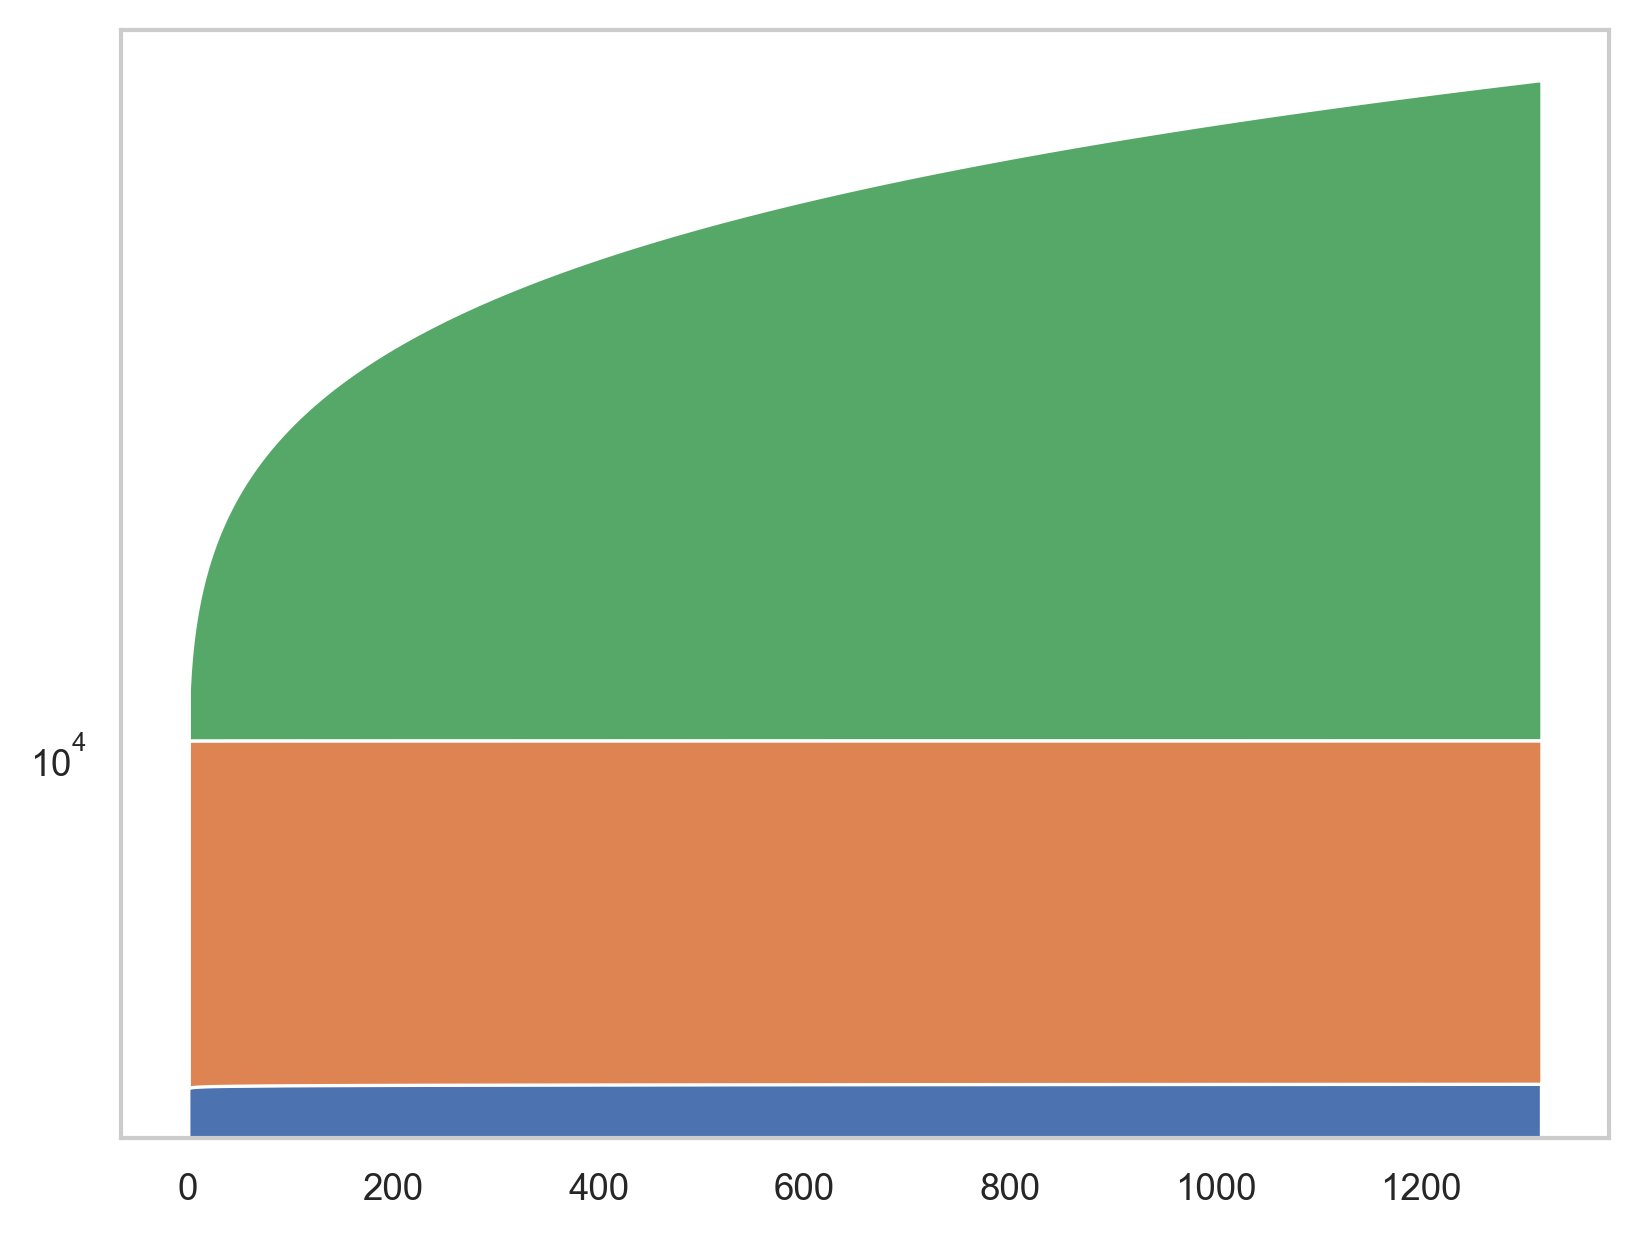

In [18]:
# Log-linear plot
fig, ax = plt.subplots()

ax.stackplot(x, y_core, y_acc, y_rare)
ax.set_yscale('log')
ax.grid(False)
plt.show()
# plt.savefig("heaps_plot.pdf", format="pdf", bbox_inches="tight")